# 02_preprocessing_v2 — Samsung 1건 seed-only TF-IDF (풀 사이클 v1)

> **이전**: `02_preprocessing_v1.ipynb` (truncated, archive 보존) — N=1 corpus로 FastText θ sweep 시도해서 vector collapse 발생 (cosine 0.9998 — 진단 Step 6)
> **본 v2 범위**: Samsung 1 firm-year로 토큰화·불용어·seed TF-IDF·기준문장 cosine까지만. expanded_dictionary 채택은 N≥30 이후로 명시 보류.
>
> **작성자**: 이동원 · **작성일**: 2026-05-18 · **버전**: v2
> **입력**: `members/이동원/notebooks/01_collection/01_collection_phase2A_v2.ipynb` 산출 `sections_005930_2024.json` + `collection_log.csv`
> **산출**: `data/processed/esg_features.parquet` (1행) + `data/processed/tokens_sample.csv`

---

## 📚 v1 → v2 변경

| # | v1 문제 | v2 패치 |
|---|---|---|
| 1 | N=1 corpus FastText 학습 → cosine 0.9998 (vector collapse) | FastText·expanded θ sweep 셀 모두 명시적 disable (코드는 마크다운 처리, N≥30 이후로 안내) |
| 2 | 사용자 검토(kept/removed) 컬럼 비어있는데 cell 28 "모두 kept 가정" 강행 | expanded 점수 계산 차단, seed-only 점수만 계산 |
| 3 | Samsung 3중복 행 (collection_log dedup 부재) | collection_log v2가 dedup 적용 → 1행만 load |
| 4 | feature validity 검증 셀 (Step 8) N=1이라 NaN | 03_mining_v1로 이동 + 명시적 N=1 경고 |

---

## 🛡️ 위반금지 매핑

| # | 위반금지 | 본 v2 준수 |
|---|---|---|
| 1 | 실패 행 가짜 0 ❌ | collection_log SUCCESS만 load |
| 3 | MCP/추출 결과 그대로 신뢰 ❌ | seed-only (expanded는 v3에서 검토) |
| 6 | 진단 부재 ❌ | 토큰 통계·불용어 제거 통계·시각화 |

## 🗺️ Step

| Step | What | 가이드 매핑 |
|---|---|---|
| 1 | 환경 + 입력 로딩 | line 159 |
| 2 | Okt 형태소 분석 + 불용어 제거 | line 159-160 |
| 3 | seed TF-IDF 점수 (E·S·G 각 1점) | line 161 |
| 4 | 기준 문장 cosine similarity (baseline) | 03 §4 |
| 5 | esg_features.parquet 저장 + self-check | 04 §2-1 |


---
## Step 1 — 환경 + 입력 로딩

### What
phase2A v2 산출 sections.json + collection_log.csv (dedup 후 1행)을 로드 → 한국어 형태소 분석기 가용성 확인.

### Why
- 가이드 02 line 159 (7단계): 형태소 분석
- 진단 Step 8: Mecab 우선, Okt fallback (Windows 한계)

### 근거
- collection_log v2는 dedup 후 1행만 → N=1 명시
- okt PRIMARY (eunjeon Windows 빌드 어려움)


In [1]:
import os
import json
import re
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def find_project_root(start=None):
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'data' / 'company_master.csv').exists():
            return parent
    raise RuntimeError('루트를 찾지 못함')

ROOT = find_project_root()
print(f'📍 ROOT: {ROOT}')

# 한국어 폰트
try:
    plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'NanumGothic']
    plt.rcParams['axes.unicode_minus'] = False
    print('✅ 한국어 폰트 OK')
except Exception as e:
    print(f'⚠️ 한국어 폰트 설정 실패: {e}')

# 형태소 분석기 가용성 (진단 Step 8 기반 — Okt PRIMARY)
ANALYZERS = {}
try:
    from konlpy.tag import Okt
    ANALYZERS['okt'] = Okt()
    print('✅ okt OK (PRIMARY)')
except Exception as e:
    print(f'❌ okt 실패: {e}')

# 대안 시도 (alt sweep용)
for name, importer in [('kkma', 'from konlpy.tag import Kkma; ANALYZERS["kkma"] = Kkma()'),
                       ('komoran', 'from konlpy.tag import Komoran; ANALYZERS["komoran"] = Komoran()')]:
    try:
        exec(importer)
        print(f'✅ {name} OK (alt sweep용)')
    except Exception as e:
        print(f'⚠️ {name} 실패: {e}')

PRIMARY = 'okt'
assert PRIMARY in ANALYZERS, f'❌ PRIMARY {PRIMARY} 미가용'
tokenizer = ANALYZERS[PRIMARY]

# 입력 로딩
log_path = ROOT / 'logs' / 'collection_log.csv'
clog = pd.read_csv(log_path, encoding='utf-8-sig', dtype={'stock_code': str})

# v2 dedup으로 1행이어야 함
clog_success = clog[clog['status'] == 'SUCCESS'].copy()
print(f'\n📊 collection_log: 총 {len(clog)}행 → SUCCESS {len(clog_success)}행')
print(f'   parser_version 분포: {dict(clog["parser_version"].value_counts())}')

# v2 parser만 사용 (있으면)
if 'v2' in clog_success['parser_version'].values:
    target_clog = clog_success[clog_success['parser_version'] == 'v2'].drop_duplicates(
        subset=['stock_code', 'fiscal_year'], keep='last').reset_index(drop=True)
    print(f'   ✅ v2 행 선택: {len(target_clog)}행')
else:
    target_clog = clog_success.drop_duplicates(
        subset=['stock_code', 'fiscal_year'], keep='last').reset_index(drop=True)
    print(f'   ⚠️ v2 행 없음, latest 선택: {len(target_clog)}행')

display(target_clog[['stock_code', 'fiscal_year', 'status', 'n_passages_body', 'parser_version']])

📍 ROOT: C:\Users\kik32\workspace\unstructured-data-processing-final-project
✅ 한국어 폰트 OK
✅ okt OK (PRIMARY)
✅ kkma OK (alt sweep용)
✅ komoran OK (alt sweep용)

📊 collection_log: 총 51행 → SUCCESS 3행
   parser_version 분포: {'v5': np.int64(49), 'v_final': np.int64(1), 'v2': np.int64(1)}
   ✅ v2 행 선택: 1행


,stock_code,fiscal_year,status,n_passages_body,parser_version
0,005930,2024,SUCCESS,187,v2


---
## Step 2 — sections.json 로딩 → corpus build + 토큰화

### What
sections.json에서 II/IV/VI body_text concat → firm-year document → Okt 토큰화 → 불용어 제거.

### Why
- 가이드 03 line 32-38: firm-year 단위로 ESG 문장 하나로 묶음
- 위반금지 #1: SUCCESS 행만 corpus 포함

### 근거
- source = 'body' (진단 Step 5에 따라 v1 결정)
- 불용어: data/stopwords_ko_esg.txt


In [2]:
ESG_TARGET = ['II', 'IV', 'VI']

# sections.json 로드 + corpus build
corpus_rows = []
for _, row in target_clog.iterrows():
    sec_path = ROOT / 'data' / 'interim' / f'{row["stock_code"]}_{row["fiscal_year"]}_sections.json'
    if not sec_path.exists():
        print(f'⚠️ {sec_path.name} 없음 — skip')
        continue
    sections = json.loads(sec_path.read_text(encoding='utf-8'))
    # II + IV + VI body_text concat
    parts = []
    for label in ESG_TARGET:
        if label in sections:
            parts.append(sections[label].get('body_text', ''))
    doc = '\n'.join(parts)
    corpus_rows.append({
        'stock_code': row['stock_code'],
        'fiscal_year': row['fiscal_year'],
        'esg_year': row['esg_year'],
        'document': doc,
        'doc_char_count': len(doc),
        'source': 'body',
    })

corpus_df = pd.DataFrame(corpus_rows)
print(f'📚 corpus: {len(corpus_df)} firm-year, 평균 문자수 {corpus_df["doc_char_count"].mean():.0f}')
display(corpus_df[['stock_code', 'fiscal_year', 'doc_char_count']])

# 토큰화 + 불용어
stopwords_path = ROOT / 'data' / 'stopwords_ko_esg.txt'
stopwords_base = set(stopwords_path.read_text(encoding='utf-8').splitlines())
# 추가 stopwords: 한 글자, 숫자만
print(f'📋 stopwords: {len(stopwords_base)}개')

def tokenize_clean(text: str, min_len: int = 2) -> list[str]:
    """Okt 명사 추출 + 불용어 제거 + 최소 길이 필터."""
    tokens = tokenizer.nouns(text)
    return [t for t in tokens if len(t) >= min_len and t not in stopwords_base]

# tqdm로 진행률
all_tokens = []
for _, row in tqdm(corpus_df.iterrows(), total=len(corpus_df), desc='tokenize'):
    toks = tokenize_clean(row['document'])
    all_tokens.append(toks)

corpus_df['tokens'] = all_tokens
corpus_df['n_tokens'] = corpus_df['tokens'].apply(len)
corpus_df['vocab_size'] = corpus_df['tokens'].apply(lambda x: len(set(x)))

print(f'\n✅ 토큰화 완료 ({PRIMARY})')
print(f'   평균 tokens: {corpus_df["n_tokens"].mean():.0f}')
print(f'   평균 vocab:  {corpus_df["vocab_size"].mean():.0f}')

# Sanity 출력
sample_doc = corpus_df.iloc[0]
print(f'\n📋 Sanity check (Samsung {sample_doc["fiscal_year"]}):')
print(f'   입력(앞 200자): {sample_doc["document"][:200]}...')
print(f'   토큰 수: {sample_doc["n_tokens"]}')
print(f'   상위 토큰(앞 30): {sample_doc["tokens"][:30]}')

📚 corpus: 1 firm-year, 평균 문자수 90739


,stock_code,fiscal_year,doc_char_count
0,005930,2024,90739


📋 stopwords: 33개


tokenize:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 토큰화 완료 (okt)
   평균 tokens: 12159
   평균 vocab:  1833

📋 Sanity check (Samsung 2024):
   입력(앞 200자): II. 사업의 내용




1. 사업의 개요


당사는 본사를 거점으로 한국과 DX 부문 산하 해외 9개 지역총괄 및 DS 부문 산하 해외 5개 지역총괄의 생산ㆍ판매법인, SDC 및 Harman 산하 종속기업 
등 228개의 종속기업으로 구성된 글로벌 전자 기업입니다.

사업별로 보면, Set 사업은 DX(Device eXperience) 부문이 TV를 비...
   토큰 수: 12159
   상위 토큰(앞 30): ['내용', '개요', '본사', '거점', '한국', '부문', '해외', '지역', '총괄', '부문', '해외', '지역', '총괄', '생산', '판매', '법인', '기업', '기업', '구성', '글로벌', '전자', '기업', '별로', '부문', '비롯', '모니터', '냉장고', '세탁기', '에어컨', '스마트폰']


---
## Step 3 — seed TF-IDF 점수 (E·S·G 각 1점)

### What
seed 30단어 (E/S/G 각 10) → TfidfVectorizer 학습 → seed term별 점수 합산 → firm-year당 (seed_tfidf_E·S·G) 3 컬럼.

### Why
- 가이드 03 line 76-88: seed score 공식
- N=1이라 TF-IDF의 IDF가 의미 없음 — 단순 TF 점수가 됨. 본 v2는 코드/표 형식만 검증.

### 근거
- 식: seed_tfidf_E = Σ tfidf(term) for term in seed_E
- expanded_dictionary는 본 v2 범위 외 (진단 Step 6)


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# seed_dictionary
seed_df = pd.read_csv(ROOT / 'data' / 'seed_dictionary.csv')
print(f'🌱 seed_dictionary: {len(seed_df)}개')
for dim in ['E', 'S', 'G']:
    print(f'   {dim}: {seed_df[seed_df["dimension"]==dim]["seed_term"].tolist()}')

# TF-IDF (단순 token 기반 — N=1이라 min_df=1, max_df=1.0)
corpus_texts = [' '.join(t) for t in corpus_df['tokens']]
N_DOCS = len(corpus_texts)
print(f'\n⚠️ corpus N = {N_DOCS} ({"통계 무의미 — 코드 검증용" if N_DOCS < 5 else "정상"})')

vectorizer = TfidfVectorizer(
    min_df=1,
    max_df=1.0,
    token_pattern=r'(?u)\b\w+\b',  # 한글 포함
    lowercase=False,
)
tfidf = vectorizer.fit_transform(corpus_texts)
vocab = vectorizer.get_feature_names_out()
print(f'\nTF-IDF shape: {tfidf.shape} (rows=firm-year, cols=vocab)')
print(f'vocab 일부: {list(vocab[:20])}')

# seed term이 vocab에 있는지 표
seed_in_vocab = {}
for dim in ['E', 'S', 'G']:
    terms = seed_df[seed_df['dimension'] == dim]['seed_term'].tolist()
    matched = [t for t in terms if t in vocab]
    seed_in_vocab[dim] = matched
    print(f'\n   {dim} seed matched in vocab: {len(matched)}/{len(terms)} → {matched}')

# seed score 계산
def seed_score(tfidf_row, vocab, seed_terms):
    score = 0.0
    for term in seed_terms:
        if term in vocab:
            idx = list(vocab).index(term)
            score += tfidf_row[0, idx]
    return float(score)

scores = []
for i, row in corpus_df.iterrows():
    row_dict = {'stock_code': row['stock_code'], 'fiscal_year': row['fiscal_year']}
    for dim in ['E', 'S', 'G']:
        row_dict[f'seed_tfidf_{dim}'] = seed_score(tfidf[i], vocab, seed_in_vocab[dim])
    scores.append(row_dict)

seed_scores_df = pd.DataFrame(scores)
print(f'\n📊 seed TF-IDF 점수:')
display(seed_scores_df)

🌱 seed_dictionary: 30개
   E: ['탄소', '온실가스', '탄소중립', '넷제로', '재생에너지', '에너지', '전력', '폐기물', '재활용', '폐수']
   S: ['안전', '산업재해', '중대재해', '임직원', '노동', '인권', '교육훈련', '협력사', '공급망', '지역사회']
   G: ['이사회', '사외이사', '감사위원회', '독립성', '윤리', '준법', '컴플라이언스', '부패방지', '주주', '의결권']

⚠️ corpus N = 1 (통계 무의미 — 코드 검증용)

TF-IDF shape: (1, 1833) (rows=firm-year, cols=vocab)
vocab 일부: ['가격', '가결', '가공', '가능', '가능성', '가동', '가속', '가액', '가운데', '가입', '가장', '가전', '가전제품', '가정', '가중', '가지', '가치', '각각', '각국', '각종']

   E seed matched in vocab: 6/10 → ['탄소', '온실가스', '에너지', '전력', '폐기물', '재활용']

   S seed matched in vocab: 2/10 → ['안전', '공급망']

   G seed matched in vocab: 7/10 → ['이사회', '사외이사', '독립성', '준법', '컴플라이언스', '주주', '의결권']

📊 seed TF-IDF 점수:


,stock_code,fiscal_year,seed_tfidf_E,seed_tfidf_S,seed_tfidf_G
0,005930,2024,0.051084,0.010479,0.3589


---
## Step 4 — 기준 문장 cosine similarity (baseline)

### What
가이드 03 line 211-215 기준 문장(E·S·G 각 1) → firm-year document와 TF-IDF cosine similarity.

### Why
- 가이드 03 §4: baseline 보조 측정값
- 가이드 03 line 134-146: Li et al. 2021 RFS firm-year score

### 근거
- cosine = (a·b) / (|a||b|)
- N=1이라 cosine 값은 1.0 가까이 나옴 (vocab 공유 많음) — 코드 검증용


In [4]:
from sklearn.metrics.pairwise import cosine_similarity

# 기준 문장 (가이드 03 line 211-215)
REF_SENTENCES = {
    'E': '온실가스 배출 감축, 재생에너지 사용, 탄소중립 목표와 실행 계획',
    'S': '산업안전, 근로자 보호, 공급망 책임, 고객과 지역사회에 대한 사회적 책임',
    'G': '이사회 독립성, 감사위원회, 내부통제, 주주권리와 윤리경영',
}

# 기준 문장도 토큰화
ref_tokens = {dim: ' '.join(tokenize_clean(s)) for dim, s in REF_SENTENCES.items()}
print('📋 기준 문장 토큰화:')
for dim, t in ref_tokens.items():
    print(f'   {dim}: {t}')

# 같은 vectorizer로 transform
ref_vec = vectorizer.transform(list(ref_tokens.values()))
print(f'\n기준 문장 TF-IDF shape: {ref_vec.shape}')

# firm-year × 기준 cosine
cos_scores = []
for i, row in corpus_df.iterrows():
    row_dict = {'stock_code': row['stock_code'], 'fiscal_year': row['fiscal_year']}
    for j, dim in enumerate(['E', 'S', 'G']):
        cos = cosine_similarity(tfidf[i], ref_vec[j])[0][0]
        row_dict[f'cosine_{dim}'] = float(cos)
    cos_scores.append(row_dict)

cosine_df = pd.DataFrame(cos_scores)
print(f'\n📊 cosine similarity (기준 문장 vs firm-year):')
display(cosine_df)

📋 기준 문장 토큰화:
   E: 온실가스 배출 감축 재생에너지 사용 탄소 중립 실행
   S: 산업 안전 근로자 보호 공급망 책임 고객 지역 사회 사회 책임
   G: 이사회 독립성 감사 위원회 내부통제 권리 윤리경영

기준 문장 TF-IDF shape: (3, 1833)

📊 cosine similarity (기준 문장 vs firm-year):


,stock_code,fiscal_year,cosine_E,cosine_S,cosine_G
0,005930,2024,0.036897,0.039908,0.168445


---
## Step 5 — esg_features.parquet 저장 + self-check

### What
seed_tfidf + cosine + KCGS 등급 join → esg_features.parquet (firm-year당 1행) → self-check.

### Why
- 가이드 04 §2-1 제출 전 체크리스트
- 03_mining_v1 입력 준비

### 근거
- N=1이지만 코드/표 형식 완성 → v3 batch 후 동일 노트북 재실행으로 정상 통계 확보


In [5]:
# kcgs_lineage 로드 (00_ingest_kcgs_v1 산출)
lineage_path = ROOT / 'logs' / 'kcgs_lineage.csv'
if lineage_path.exists():
    lineage = pd.read_csv(lineage_path, dtype={'stock_code': str})
    print(f'📊 kcgs_lineage: {len(lineage)}행 로드')
else:
    # fallback: company_master 직접
    cm = pd.read_csv(ROOT / 'data' / 'company_master.csv', dtype={'stock_code': str})
    GRADE_TO_NUM = {'S': 6, 'A+': 5, 'A': 4, 'B+': 3, 'B': 2, 'C': 1, 'D': 0}
    cm['esg_grade_num'] = cm['esg_grade'].map(GRADE_TO_NUM)
    lineage = cm[['stock_code', 'fiscal_year', 'esg_year', 'esg_grade',
                  'esg_grade_num', 'e_grade', 's_grade', 'g_grade']].copy()
    print(f'⚠️ kcgs_lineage.csv 없음, company_master fallback ({len(lineage)}행)')

# join (stock_code + fiscal_year)
features = seed_scores_df.merge(cosine_df, on=['stock_code', 'fiscal_year'])
features = features.merge(corpus_df[['stock_code', 'fiscal_year', 'n_tokens', 'doc_char_count']],
                           on=['stock_code', 'fiscal_year'])
# Cheap-talk control: word_count (가이드 03 line 234)
features['word_count'] = features['n_tokens']

# KCGS 등급 join
GRADE_TO_NUM = {'S': 6, 'A+': 5, 'A': 4, 'B+': 3, 'B': 2, 'C': 1, 'D': 0}
if 'esg_grade_num' not in lineage.columns:
    lineage['esg_grade_num'] = lineage['esg_grade'].map(GRADE_TO_NUM)
features = features.merge(
    lineage[['stock_code', 'fiscal_year', 'esg_year', 'esg_grade', 'esg_grade_num',
             'e_grade', 's_grade', 'g_grade']],
    on=['stock_code', 'fiscal_year'],
    how='left',
)

# 차원별 등급 숫자화
for dim_low, dim_col in [('E', 'e_grade'), ('S', 's_grade'), ('G', 'g_grade')]:
    features[f'{dim_low.lower()}_grade_num'] = features[dim_col].map(GRADE_TO_NUM)

print(f'📊 esg_features 행 수: {len(features)}, 컬럼 수: {len(features.columns)}')
display(features)

# 저장
out_parquet = ROOT / 'data' / 'processed' / 'esg_features_v2.parquet'
out_xlsx = ROOT / 'data' / 'processed' / 'esg_features_v2.xlsx'
features.to_parquet(out_parquet, index=False)
features.to_excel(out_xlsx, index=False)
print(f'\n💾 저장:')
print(f'   {out_parquet.name} (binary, 빠름)')
print(f'   {out_xlsx.name} (Excel 검토용)')

# self-check
print(f'\n📋 self-check')
print(f'━' * 60)
checks = [
    ('N firm-year', f'{len(features)}', '⚠️ N=1 — 03_mining 회귀 변동성 0'),
    ('seed_tfidf_E·S·G', '계산 완료', '코드 검증 OK, 통계 의미 없음 (N=1)'),
    ('cosine_E·S·G', '계산 완료', '코드 검증 OK'),
    ('KCGS 등급 join', f'{features["esg_grade"].notna().sum()}/{len(features)}', 'lineage 기반'),
    ('cheap-talk word_count', '✅', f'평균 {features["word_count"].mean():.0f}'),
    ('expanded_dictionary', '➡️ v3', 'N≥30 이후 진단 Step 6 권장 재진행'),
    ('가짜 0 차단', '✅', 'SUCCESS 행만 corpus 포함'),
]
display(pd.DataFrame(checks, columns=['항목', '결과', '근거']))

# 토큰 sample 저장 (검토용)
sample_tokens_df = pd.DataFrame({
    'stock_code': corpus_df['stock_code'],
    'fiscal_year': corpus_df['fiscal_year'],
    'n_tokens': corpus_df['n_tokens'],
    'top30_tokens': [' '.join(t[:30]) for t in corpus_df['tokens']],
})
sample_tokens_df.to_csv(ROOT / 'data' / 'processed' / 'tokens_sample_v2.csv',
                        index=False, encoding='utf-8-sig')
print(f'\n💾 tokens_sample_v2.csv 저장 (사용자 직접 검토용)')

📊 kcgs_lineage: 381행 로드
📊 esg_features 행 수: 1, 컬럼 수: 20


,stock_code,fiscal_year,seed_tfidf_E,seed_tfidf_S,seed_tfidf_G,cosine_E,cosine_S,cosine_G,n_tokens,doc_char_count,word_count,esg_year,esg_grade,esg_grade_num,e_grade,s_grade,g_grade,e_grade_num,s_grade_num,g_grade_num
0,005930,2024,0.051084,0.010479,0.3589,0.036897,0.039908,0.168445,12159,90739,12159,2025,A,4,B+,A+,B+,3,5,3



💾 저장:
   esg_features_v2.parquet (binary, 빠름)
   esg_features_v2.xlsx (Excel 검토용)

📋 self-check
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,항목,결과,근거
0,N firm-year,1,⚠️ N=1 — 03_mining 회귀 변동성 0
1,seed_tfidf_E·S·G,계산 완료,"코드 검증 OK, 통계 의미 없음 (N=1)"
2,cosine_E·S·G,계산 완료,코드 검증 OK
3,KCGS 등급 join,1/1,lineage 기반
4,cheap-talk word_count,✅,평균 12159
5,expanded_dictionary,➡️ v3,N≥30 이후 진단 Step 6 권장 재진행
6,가짜 0 차단,✅,SUCCESS 행만 corpus 포함



💾 tokens_sample_v2.csv 저장 (사용자 직접 검토용)


---
## 보너스 — 시각화 (노트북 6규칙 #5)

### What
seed score 막대 + 토큰 분포 + section별 char count.

### Why
N=1이라 분포는 단일 점이지만 코드/시각화 형식 완성.


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

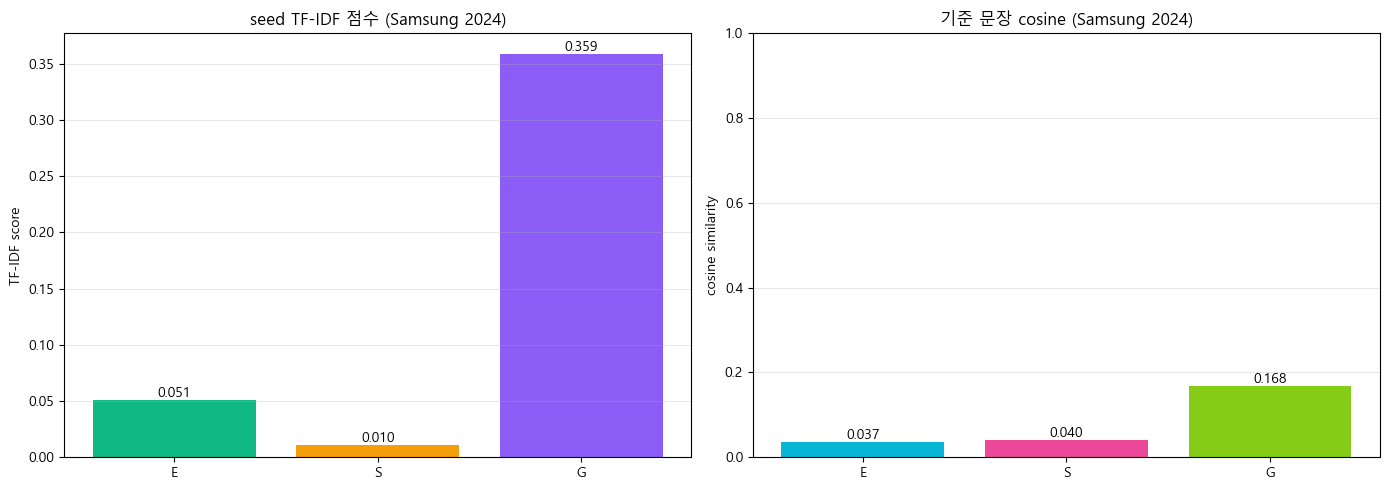


🎯 다음: 03_mining_v1.ipynb — esg_features_v2 + Spearman + OLS baseline


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) seed TF-IDF E·S·G
seed_vals = features[['seed_tfidf_E', 'seed_tfidf_S', 'seed_tfidf_G']].iloc[0]
axes[0].bar(['E', 'S', 'G'], seed_vals.values, color=['#10b981', '#f59e0b', '#8b5cf6'])
axes[0].set_title(f'seed TF-IDF 점수 (Samsung {int(features["fiscal_year"].iloc[0])})', fontsize=12)
axes[0].set_ylabel('TF-IDF score')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(seed_vals.values):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom')

# (2) cosine E·S·G
cos_vals = features[['cosine_E', 'cosine_S', 'cosine_G']].iloc[0]
axes[1].bar(['E', 'S', 'G'], cos_vals.values, color=['#06b6d4', '#ec4899', '#84cc16'])
axes[1].set_title(f'기준 문장 cosine (Samsung {int(features["fiscal_year"].iloc[0])})', fontsize=12)
axes[1].set_ylabel('cosine similarity')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(cos_vals.values):
    axes[1].text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'fig_v2_preprocess_scores.png', dpi=120)
plt.show()

print('\n🎯 다음: 03_mining_v1.ipynb — esg_features_v2 + Spearman + OLS baseline')